In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [34]:
data = pd.read_csv("C:\Titanic_Dataset.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [35]:
data.shape

(891, 12)

In [36]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [37]:
data.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [38]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [39]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## HANDLING MISSING VALUES

In [40]:
numeric_cols = [val for val in data.columns if data[val].dtypes != object]
numeric_cols

['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

In [41]:
numeric_data = data[numeric_cols]
numeric_data.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


In [42]:
numeric_data.corr()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


<Axes: >

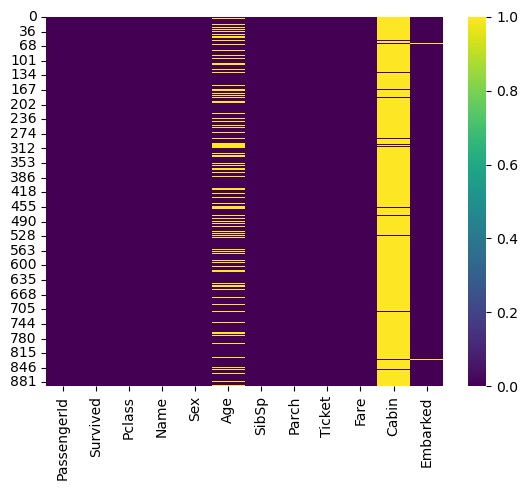

In [43]:
missing_values = data[data.isnull().any(axis = 1)]
sns.heatmap(missing_values.isnull(), cmap = 'viridis', cbar = True)

In [44]:
data.drop('Cabin', axis=1, inplace=True)

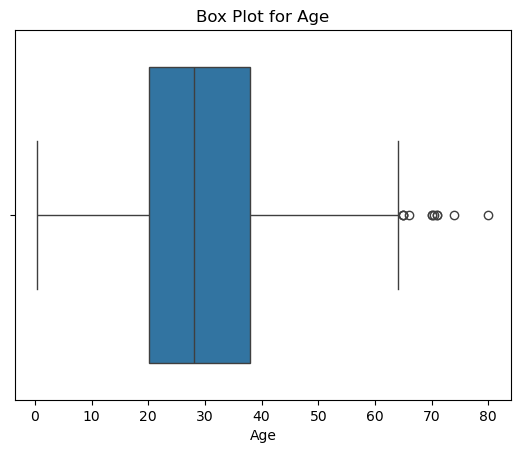

In [45]:
sns.boxplot(x=data['Age'])
plt.title("Box Plot for Age")
plt.show()

In [46]:
data['Age'].fillna(data['Age'].median(), inplace=True)

In [47]:
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

In [48]:
data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## FEATURE ENGINEERING

In [49]:
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1

In [50]:
data['AgeGroup'] = pd.cut(
    data['Age'],
    bins=[0, 12, 20, 40, 60, 80],
    labels=['Child', 'Teen', 'Adult', 'MiddleAge', 'Senior']
)

In [51]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'FamilySize', 'AgeGroup'],
      dtype='object')

## ENCODING CATEGORICAL VARIABLES

In [52]:
data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})

In [53]:
data.Sex.unique()

array([0, 1])

In [54]:
data = pd.get_dummies(data, columns=['Embarked'], drop_first=True)

In [55]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'FamilySize', 'AgeGroup', 'Embarked_Q',
       'Embarked_S'],
      dtype='object')

## UNIVARIATE ANALYSIS

In [56]:
data['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

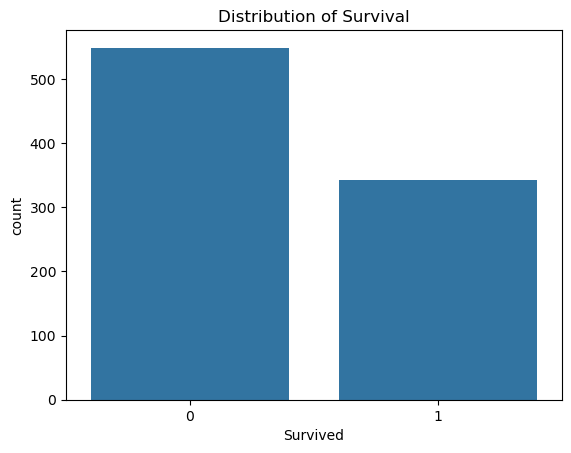

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Survived', data=data)
plt.title('Distribution of Survival')
plt.show()

In [58]:
data['Sex'].value_counts()

Sex
0    577
1    314
Name: count, dtype: int64

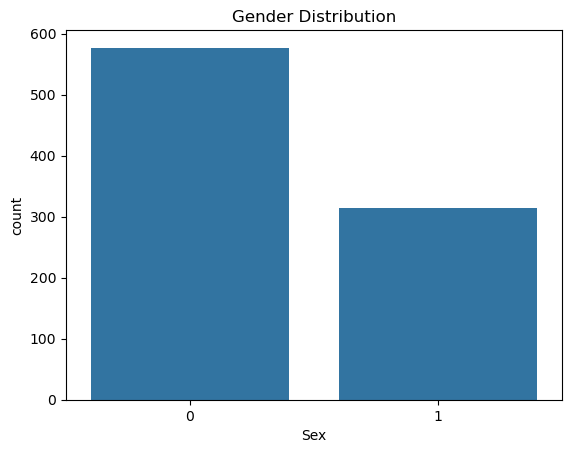

In [59]:
sns.countplot(x='Sex', data=data)
plt.title('Gender Distribution')
plt.show()

In [60]:
data['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

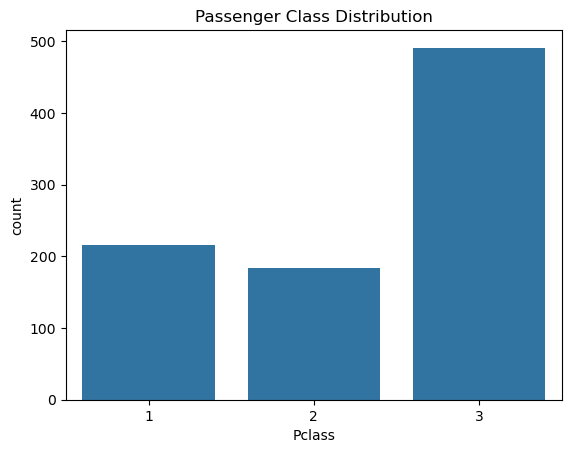

In [61]:
sns.countplot(x='Pclass', data=data)
plt.title('Passenger Class Distribution')
plt.show()

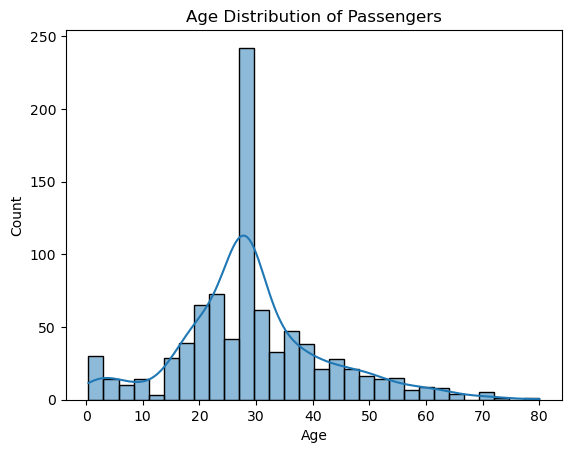

In [62]:
sns.histplot(data['Age'], bins=30, kde=True)
plt.title('Age Distribution of Passengers')
plt.show()

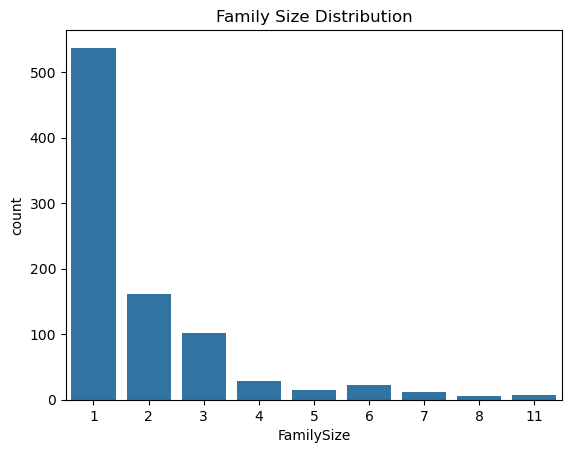

In [63]:
sns.countplot(x='FamilySize', data=data)
plt.title('Family Size Distribution')
plt.show()

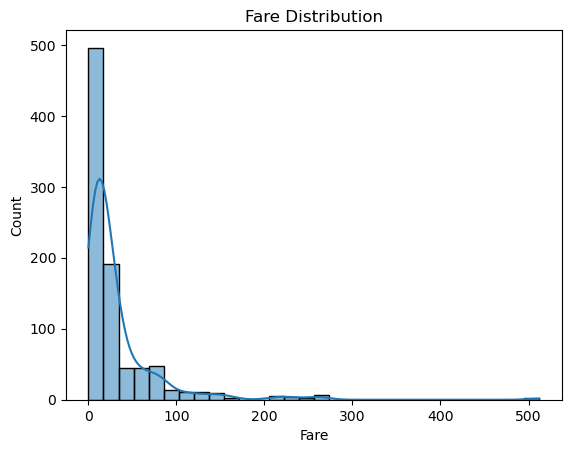

In [64]:
sns.histplot(data['Fare'], bins=30, kde=True)
plt.title('Fare Distribution')
plt.show()

## BIVARIATE ANALYSIS

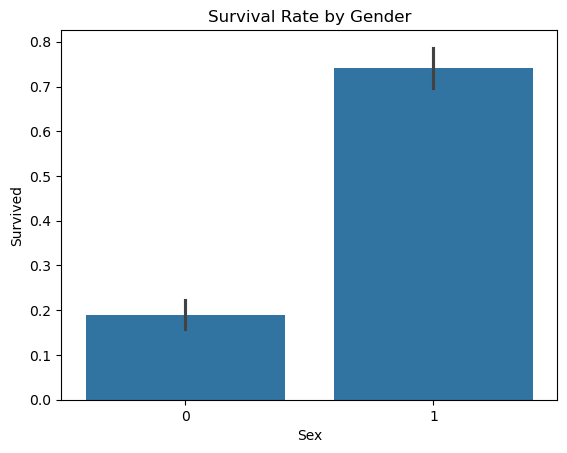

In [65]:
sns.barplot(x='Sex', y='Survived', data=data)
plt.title('Survival Rate by Gender')
plt.show()

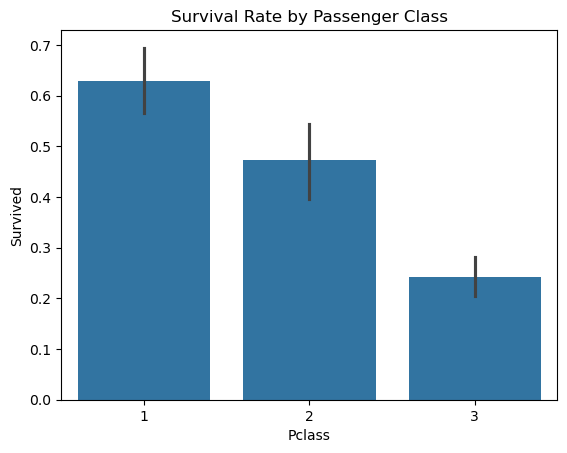

In [66]:
sns.barplot(x='Pclass', y='Survived', data=data)
plt.title('Survival Rate by Passenger Class')
plt.show()

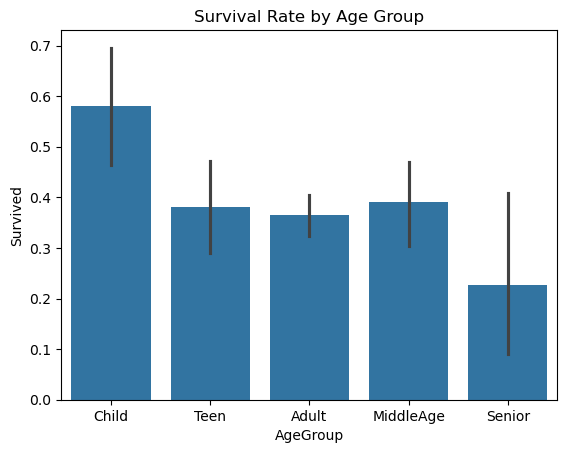

In [67]:
sns.barplot(x='AgeGroup', y='Survived', data=data)
plt.title('Survival Rate by Age Group')
plt.show()

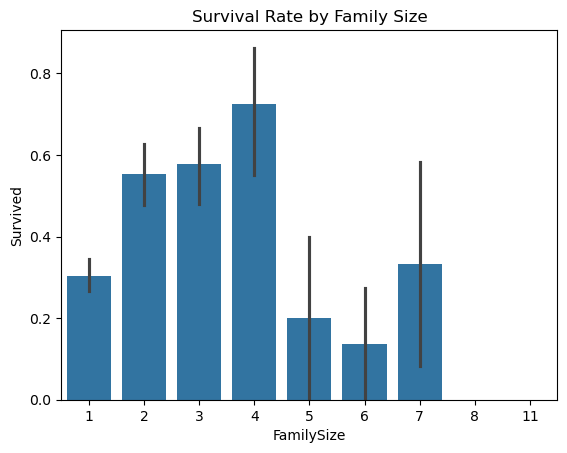

In [68]:
sns.barplot(x='FamilySize', y='Survived', data=data)
plt.title('Survival Rate by Family Size')
plt.show()

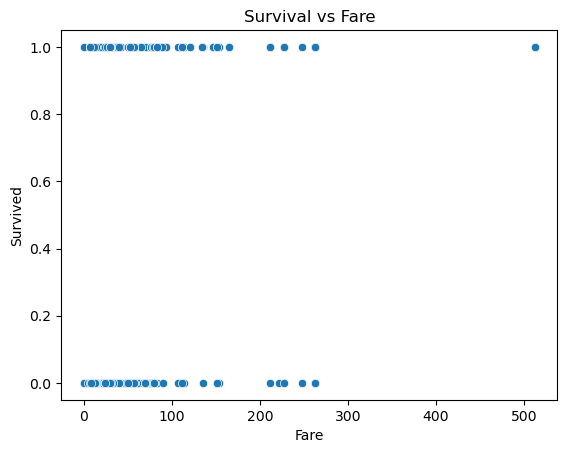

In [69]:
sns.scatterplot(x='Fare', y='Survived', data=data)
plt.title('Survival vs Fare')
plt.show()

## MULTIVARIATE ANALYSIS

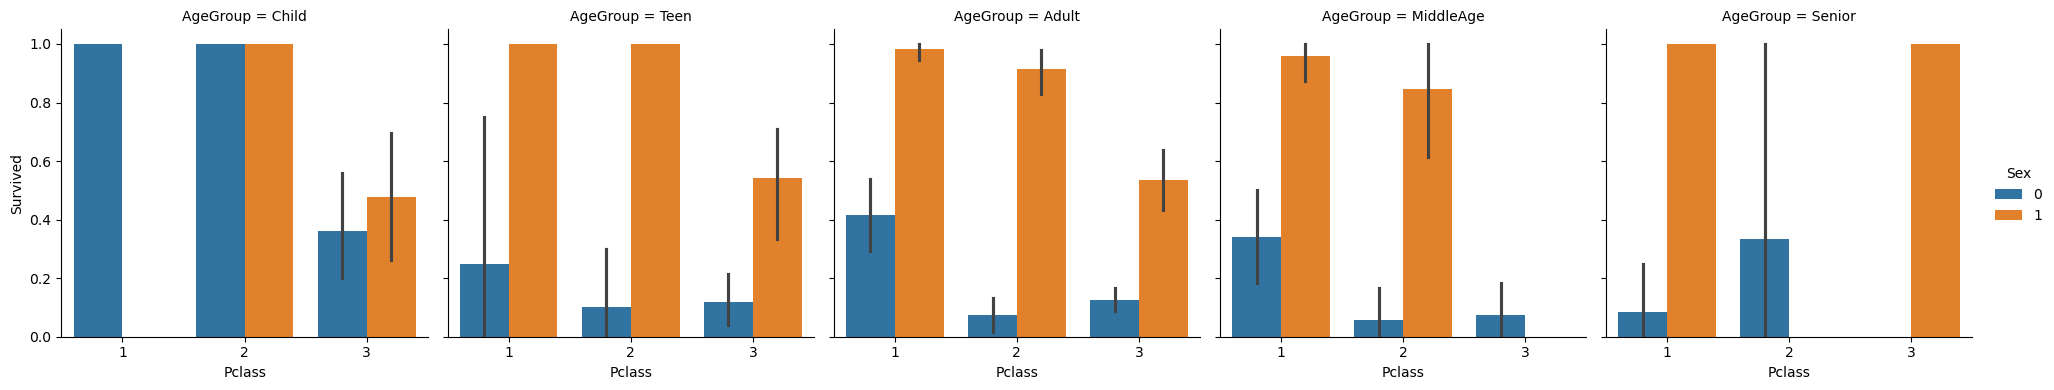

In [70]:
sns.catplot(x='Pclass', y='Survived', hue='Sex', col='AgeGroup',
            data=data, kind='bar', height=4, aspect=1)
plt.show()

## CORRELATION ANALYSIS

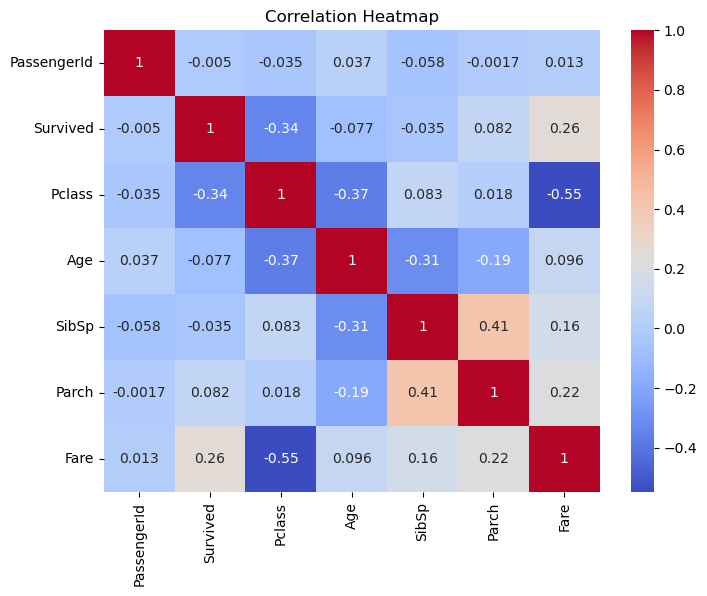

In [71]:
plt.figure(figsize=(8,6))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [72]:
from sklearn.preprocessing import StandardScaler
standardScaler = StandardScaler()
data[numeric_cols] = standardScaler.fit_transform(data[numeric_cols])

In [73]:
from sklearn.preprocessing import MinMaxScaler
minMaxScaler = MinMaxScaler()
x = minMaxScaler.fit_transform(data[numeric_cols])